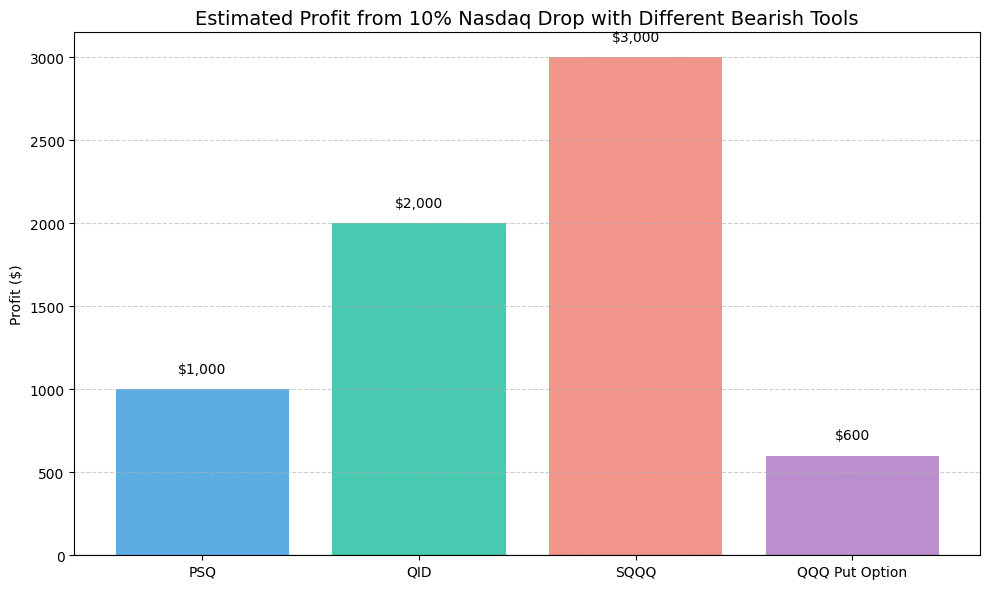

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 假设当前纳指（QQQ）指数价格
qqq_current = 440  # 假设当前QQQ在440左右

# 假设用户预测QQQ将回调10%
qqq_drop_percent = 0.10
qqq_target = qqq_current * (1 - qqq_drop_percent)

# 计算三种ETF的理论涨幅（不考虑每日衰减，只为近似说明）
psq_return = qqq_drop_percent  # PSQ 反向1倍
qid_return = qqq_drop_percent * 2  # QID 反向2倍
sqqq_return = qqq_drop_percent * 3  # SQQQ 反向3倍

# 构建数据
strategies = ['PSQ', 'QID', 'SQQQ']
returns = [psq_return, qid_return, sqqq_return]

# 假设投入1万元计算对应收益
initial_investment = 10000
profits = [r * initial_investment for r in returns]

# Put期权模拟（假设购买QQQ的ATM Put期权，期权成本约为4%）
put_cost = initial_investment * 0.04
put_gain = initial_investment * qqq_drop_percent - put_cost

# 加入到列表中
strategies.append('QQQ Put Option')
profits.append(put_gain)

# 创建DataFrame展示
df = pd.DataFrame({
    'Strategy': strategies,
    'Estimated Profit ($)': profits
})

# 绘图
plt.figure(figsize=(10, 6))
bars = plt.bar(df['Strategy'], df['Estimated Profit ($)'], color=['#5DADE2', '#48C9B0', '#F1948A', '#BB8FCE'])
plt.axhline(0, color='black', linewidth=0.8)
plt.title('Estimated Profit from 10% Nasdaq Drop with Different Bearish Tools', fontsize=14)
plt.ylabel('Profit ($)')
plt.grid(axis='y', linestyle='--', alpha=0.6)

# 添加数值标签
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 100, f"${yval:,.0f}", ha='center', fontsize=10)

plt.tight_layout()
plt.show()


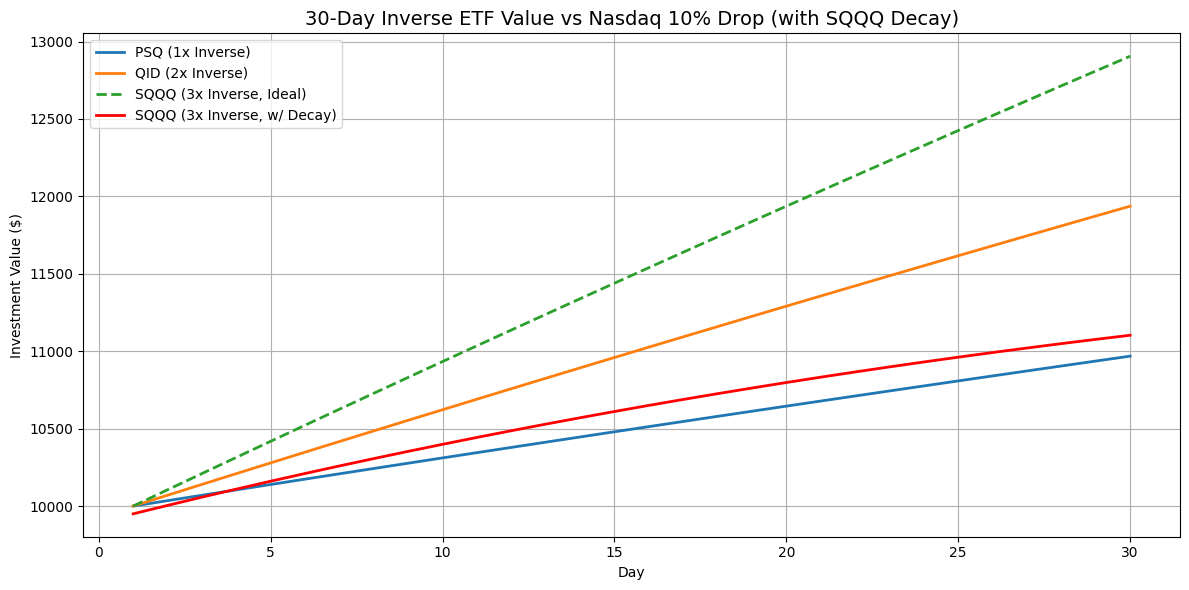

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 模拟基本参数
initial_investment = 10000
qqq_drop_percent = 0.10  # 纳指回调10%
holding_days = 30  # 假设持有30天
decay_rate_sqqq = 0.005  # 每天0.5%的时间腐蚀（年化约100%）

# 构建每日模拟数据
days = np.arange(1, holding_days + 1)
qqq_daily_return = (1 - qqq_drop_percent) ** (1 / holding_days) - 1  # 日均跌幅
qqq_prices = [1.0]  # 归一化指数

for _ in days[1:]:
    qqq_prices.append(qqq_prices[-1] * (1 + qqq_daily_return))

# 构建反向ETF走势（理论值）
psq_values = [initial_investment * (1 + (1 - p)) for p in qqq_prices]  # PSQ 理论反向1倍
qid_values = [initial_investment * (1 + 2 * (1 - p)) for p in qqq_prices]  # QID 理论反向2倍
sqqq_values_no_decay = [initial_investment * (1 + 3 * (1 - p)) for p in qqq_prices]  # SQQQ 理论反向3倍

# 加入每日时间腐蚀（复利衰减）
sqqq_values_with_decay = [val * ((1 - decay_rate_sqqq) ** day) for day, val in zip(days, sqqq_values_no_decay)]

# 创建 DataFrame
df = pd.DataFrame({
    'Day': days,
    'QQQ Price (normalized)': qqq_prices,
    'PSQ Value': psq_values,
    'QID Value': qid_values,
    'SQQQ Value (No Decay)': sqqq_values_no_decay,
    'SQQQ Value (With Decay)': sqqq_values_with_decay
})

# 绘图
plt.figure(figsize=(12, 6))
plt.plot(df['Day'], df['PSQ Value'], label='PSQ (1x Inverse)', linewidth=2)
plt.plot(df['Day'], df['QID Value'], label='QID (2x Inverse)', linewidth=2)
plt.plot(df['Day'], df['SQQQ Value (No Decay)'], label='SQQQ (3x Inverse, Ideal)', linestyle='--', linewidth=2)
plt.plot(df['Day'], df['SQQQ Value (With Decay)'], label='SQQQ (3x Inverse, w/ Decay)', color='red', linewidth=2)

plt.title('30-Day Inverse ETF Value vs Nasdaq 10% Drop (with SQQQ Decay)', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Investment Value ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
